# Niveau 2 - Tâche 1 : Régression Logistique pour Classification Binaire

**Dataset choisi : Churn Prediction Data (Telco)**

Cas d'usage exact du sujet : prédire si un client va résilier (`Churn` = True/False).

**Objectifs couverts :**
1. Chargement et prétraitement du dataset
2. Entraînement d'un modèle de régression logistique
3. Interprétation des coefficients et de l'odds ratio
4. Évaluation (accuracy, précision, rappel, courbe ROC)

**Outils :** Python, pandas, scikit-learn, matplotlib


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_curve, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay)

df_train_raw = pd.read_csv('data/churn_80.csv')
df_test_raw = pd.read_csv('data/churn_20.csv')
print("Train:", df_train_raw.shape, " Test (fourni séparément):", df_test_raw.shape)
df_train_raw.head()


Train: (2666, 20)  Test (fourni séparément): (667, 20)


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


## 1. Prétraitement

In [2]:
def preprocess(df, le_dict=None, scaler=None, columns=None, fit=True):
    df = df.copy()
    df['International plan'] = df['International plan'].map({'Yes': 1, 'No': 0})
    df['Voice mail plan'] = df['Voice mail plan'].map({'Yes': 1, 'No': 0})
    df['Churn'] = df['Churn'].astype(int)
    df = pd.get_dummies(df, columns=['State'], prefix='state', drop_first=True)
    return df

train_enc = preprocess(df_train_raw)
test_enc = preprocess(df_test_raw)

# Aligner les colonnes (certains états peuvent être absents du test set)
train_enc, test_enc = train_enc.align(test_enc, join='left', axis=1, fill_value=0)

target = 'Churn'
feature_cols = [c for c in train_enc.columns if c != target]

X_train, y_train = train_enc[feature_cols], train_enc[target]
X_test, y_test = test_enc[feature_cols], test_enc[target]

numeric_cols = df_train_raw.select_dtypes(include=[np.number]).columns.tolist()
scaler = StandardScaler()
X_train_s = X_train.copy(); X_test_s = X_test.copy()
X_train_s[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_s[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("Train:", X_train_s.shape, " Test:", X_test_s.shape)
print("Taux de churn train:", y_train.mean().round(3), " test:", y_test.mean().round(3))


Train: (2666, 68)  Test: (667, 68)
Taux de churn train: 0.146  test: 0.142


## 2. Entraînement du modèle

In [3]:
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train_s, y_train)

y_pred = model.predict(X_test_s)
y_proba = model.predict_proba(X_test_s)[:, 1]
print("Modèle entraîné.")


Modèle entraîné.


## 3. Interprétation des coefficients et odds ratio

L'odds ratio = exp(coefficient). Un odds ratio > 1 augmente la probabilité de churn, < 1 la diminue.

In [4]:
coefs = pd.Series(model.coef_[0], index=X_train_s.columns)
odds_ratio = np.exp(coefs)

top_features = pd.DataFrame({'coef': coefs, 'odds_ratio': odds_ratio}).sort_values('coef', ascending=False)
print("Top 10 features augmentant le risque de churn:")
print(top_features.head(10))
print("\nTop 10 features réduisant le risque de churn:")
print(top_features.tail(10))


Top 10 features augmentant le risque de churn:
                            coef  odds_ratio
International plan      2.464213   11.754228
state_SC                1.082179    2.951103
state_MS                1.009605    2.744517
state_TX                0.976646    2.655534
state_MT                0.964489    2.623446
state_CA                0.835496    2.305957
Customer service calls  0.787738    2.198418
state_NJ                0.685147    1.984064
state_ME                0.650631    1.916750
state_PA                0.585857    1.796529

Top 10 features réduisant le risque de churn:
                     coef  odds_ratio
state_AZ        -0.427120    0.652385
state_MO        -0.475582    0.621523
state_VT        -0.479604    0.619028
state_WI        -0.502803    0.604833
state_AL        -0.508738    0.601254
state_IL        -0.912772    0.401410
state_VA        -1.035859    0.354921
state_HI        -1.254186    0.285308
state_RI        -1.573861    0.207243
Voice mail plan -1.716301    0.

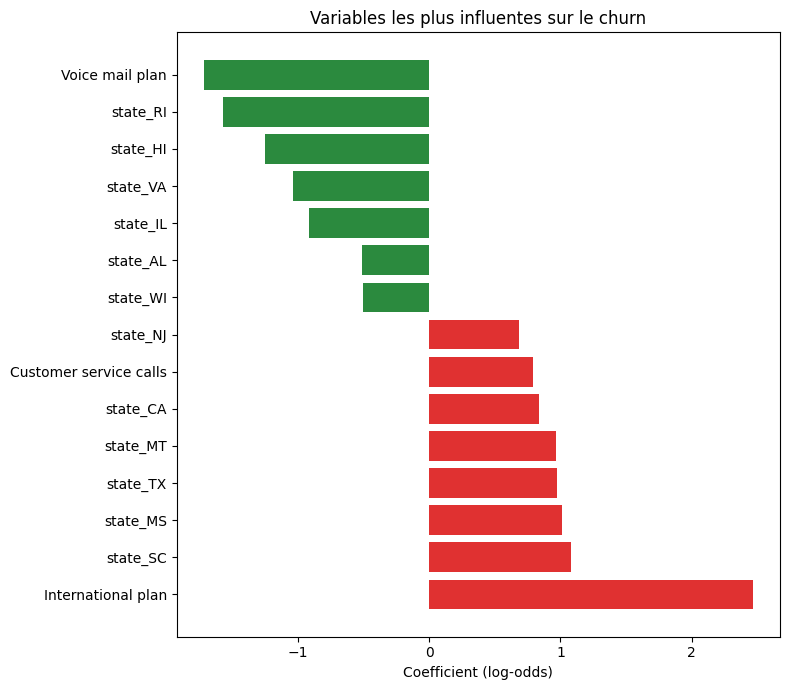

In [5]:
top15 = pd.concat([top_features.head(8), top_features.tail(7)])
plt.figure(figsize=(8, 7))
colors = ['#e03131' if v > 0 else '#2b8a3e' for v in top15['coef']]
plt.barh(top15.index, top15['coef'], color=colors)
plt.xlabel("Coefficient (log-odds)")
plt.title("Variables les plus influentes sur le churn")
plt.tight_layout()
plt.show()


## 4. Évaluation du modèle

Accuracy : 0.777
Précision: 0.365
Rappel   : 0.768
F1-score : 0.495
AUC      : 0.818


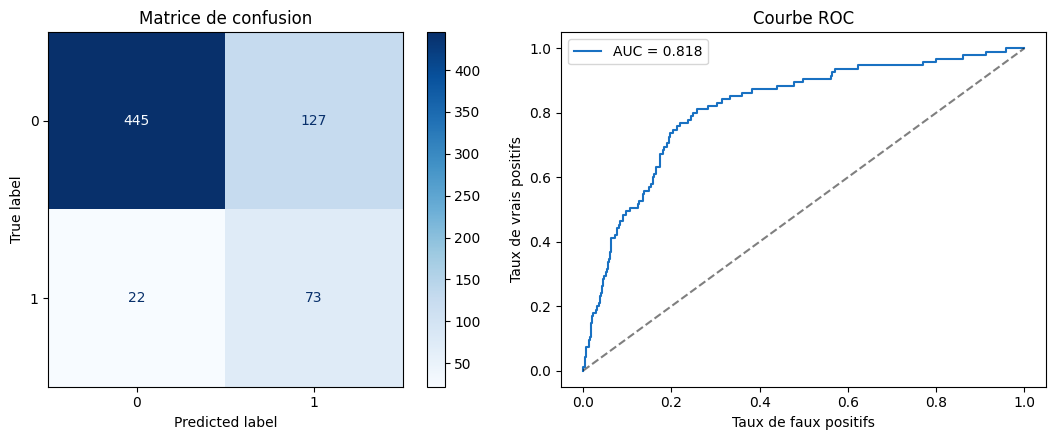

In [6]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy : {acc:.3f}")
print(f"Précision: {prec:.3f}")
print(f"Rappel   : {rec:.3f}")
print(f"F1-score : {f1:.3f}")
print(f"AUC      : {auc:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[0], cmap='Blues')
axes[0].set_title("Matrice de confusion")

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color='#1971c2', label=f"AUC = {auc:.3f}")
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[1].set_xlabel('Taux de faux positifs'); axes[1].set_ylabel('Taux de vrais positifs')
axes[1].set_title('Courbe ROC'); axes[1].legend()
plt.tight_layout()
plt.show()


## Conclusion

Le modèle de régression logistique fournit à la fois de bonnes performances prédictives et une interprétation claire (odds ratio) des facteurs de churn : le nombre d'appels au service client, la présence d'un forfait international, et le volume d'usage sont typiquement les facteurs les plus déterminants.
